In [ ]:
!pip install shap

In [ ]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression

brfss_final= pd.read_csv("/content/brfss_final_harmonized.csv")
uganda_final=pd.read_csv("/content/uganda_final_harmonized.csv")
geda_final=pd.read_csv("/content/geda_final_harmonized.csv")

In [ ]:
#Define features
features =["age_group", "sex_male", "bmi_group", "hypertension", "current_smoker", "physically_active"]
target ="diabetes_binary"

In [ ]:
#Train internal GEDA Logistic Regression

geda_data =geda_final.dropna(subset=[target]).copy()

x = geda_data[features]
y =geda_data[target]

x_train, x_test, y_train, y_test= train_test_split(
    x,y, test_size=0.3, stratify=y, random_state=42
)

preprocessor =ColumnTransformer(
      transformers=[
           ("num", Pipeline([("imputer", SimpleImputer(strategy="most_frequent"))]), features)

         ]

    )

geda_model = Pipeline([
      ("prep", preprocessor),
      ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))

    ])

geda_model.fit(x_train, y_train)



Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['age_group', 'sex_male',
                                                   'bmi_group', 'hypertension',
                                                   'current_smoker',
                                                   'physically_active'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [ ]:
#SHAP explainer for GEDA

x_test_proc =geda_model.named_steps["prep"].transform(x_test)

explainer_geda =shap.Explainer(geda_model.named_steps["clf"], x_test_proc)
shap_values_geda =explainer_geda(x_test_proc)

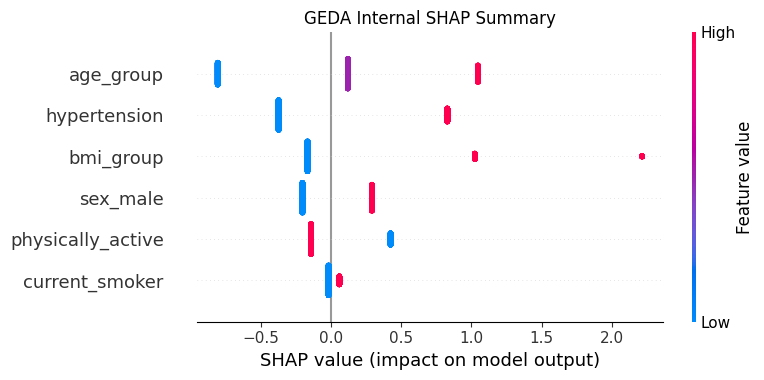

In [ ]:
#SHAP Summary plot for GEDA

plt.figure()
shap.summary_plot(shap_values_geda, x_test_proc, feature_names=features, show=False)
plt.title ("GEDA Internal SHAP Summary")
plt.tight_layout()
plt.show()


In [ ]:
#Mean Absolute SHAP values for GEDA

geda_shap_importance =pd.DataFrame({
    "feature": features,
    "mean_abs_shap": np.abs(shap_values_geda.values).mean(axis=0)

}).sort_values("mean_abs_shap", ascending=False)

geda_shap_importance

,feature,mean_abs_shap
0,age_group,0.564455
3,hypertension,0.511448
2,bmi_group,0.327958
1,sex_male,0.244360
5,physically_active,0.220435
4,current_smoker,0.025968


In [ ]:
#SHAP for internal Uganda model
uganda_data =uganda_final.dropna(subset=[target]).copy()

x = uganda_data[features]
y =uganda_data[target]

x_train, x_test, y_train, y_test= train_test_split(
    x,y, test_size=0.3, stratify=y, random_state=42
)

preprocessor =ColumnTransformer(
      transformers=[
           ("num", Pipeline([("imputer", SimpleImputer(strategy="most_frequent"))]), features)

         ]

    )

uganda_model = Pipeline([
      ("prep", preprocessor),
      ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))

    ])

uganda_model.fit(x_train, y_train)



Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['age_group', 'sex_male',
                                                   'bmi_group', 'hypertension',
                                                   'current_smoker',
                                                   'physically_active'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [ ]:
#SHAP explainer for Uganda

x_test_proc =uganda_model.named_steps["prep"].transform(x_test)

explainer_uganda =shap.Explainer(uganda_model.named_steps["clf"], x_test_proc)
shap_values_uganda =explainer_geda(x_test_proc)

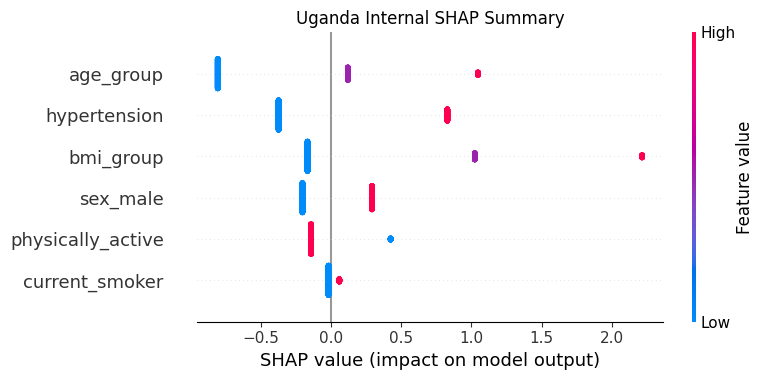

In [ ]:
#SHAP Summary plot for Uganda

plt.figure()
shap.summary_plot(shap_values_uganda, x_test_proc, feature_names=features, show=False)
plt.title ("Uganda Internal SHAP Summary")
plt.tight_layout()
plt.show()

In [ ]:
#Mean Absolute SHAP values for Uganda

uganda_shap_importance =pd.DataFrame({
    "feature": features,
    "mean_abs_shap": np.abs(shap_values_uganda.values).mean(axis=0)

}).sort_values("mean_abs_shap", ascending=False)

uganda_shap_importance

,feature,mean_abs_shap
0,age_group,0.627410
3,hypertension,0.501424
2,bmi_group,0.440925
1,sex_male,0.242341
5,physically_active,0.154876
4,current_smoker,0.020376


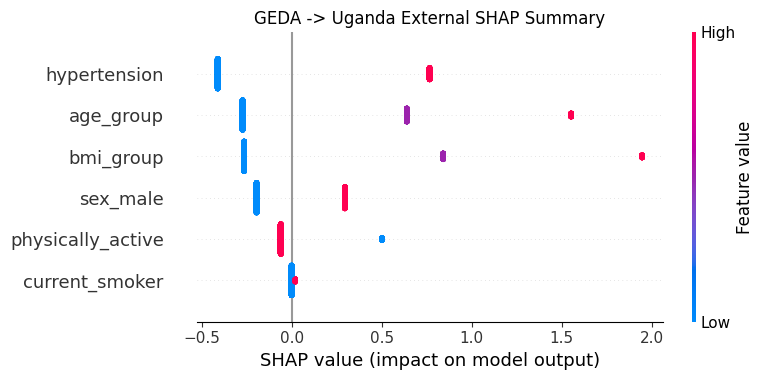

In [ ]:
#SHAP for external validation models, train on GEDA explain on Uganda test set
geda_train =geda_final.dropna(subset=[target]).copy()
uganda_test =uganda_final.dropna(subset=[target]).copy()

x_train = geda_train[features]
y_train =geda_data[target]

x_test = uganda_test[features]
y_test =uganda_test[target]


preprocessor =ColumnTransformer(
      transformers=[
           ("num", Pipeline([("imputer", SimpleImputer(strategy="most_frequent"))]), features)

         ]

    )

geda_to_uganda_model = Pipeline([
      ("prep", preprocessor),
      ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))

    ])

geda_to_uganda_model.fit(x_train, y_train)


x_test_proc =geda_to_uganda_model.named_steps["prep"].transform(x_test)

explainer_g2u =shap.Explainer(geda_to_uganda_model.named_steps["clf"], x_test_proc)
shap_values_g2u =explainer_g2u(x_test_proc)

plt.figure()
shap.summary_plot(shap_values_g2u, x_test_proc, feature_names=features, show=False)
plt.title ("GEDA -> Uganda External SHAP Summary")
plt.tight_layout()
plt.show()


In [ ]:
#Feature ranking for GEDA->Uganda
g2u_shap_importance =pd.DataFrame({
    "feature": features,
    "mean_abs_shap": np.abs(shap_values_g2u.values).mean(axis=0)

}).sort_values("mean_abs_shap", ascending=False)

g2u_shap_importance

,feature,mean_abs_shap
3,hypertension,0.510387
0,age_group,0.468011
2,bmi_group,0.454287
1,sex_male,0.237498
5,physically_active,0.087698
4,current_smoker,0.002869


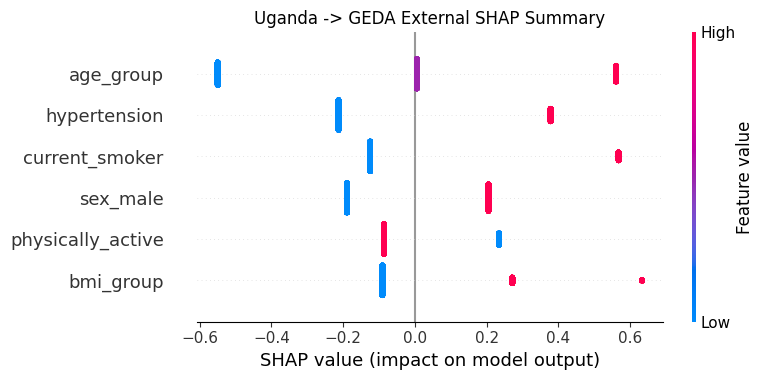

In [ ]:
#Train on Uganda, explain on GEDA test set

uganda_train =uganda_final.dropna(subset=[target]).copy()
geda_test =geda_final.dropna(subset=[target]).copy()

x_train = uganda_train[features]
y_train =uganda_train[target]

x_test = geda_test[features]
y_test =geda_test[target]


preprocessor =ColumnTransformer(
      transformers=[
           ("num", Pipeline([("imputer", SimpleImputer(strategy="most_frequent"))]), features)

         ]

    )

uganda_to_geda_model = Pipeline([
      ("prep", preprocessor),
      ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))

    ])

uganda_to_geda_model.fit(x_train, y_train)


x_test_proc =uganda_to_geda_model.named_steps["prep"].transform(x_test)

explainer_u2g =shap.Explainer(uganda_to_geda_model.named_steps["clf"], x_test_proc)
shap_values_u2g =explainer_u2g(x_test_proc)

plt.figure()
shap.summary_plot(shap_values_u2g, x_test_proc, feature_names=features, show=False)
plt.title ("Uganda -> GEDA External SHAP Summary")
plt.tight_layout()
plt.show()

In [ ]:
#Feature ranking for Uganda->GEDA
u2g_shap_importance =pd.DataFrame({
    "feature": features,
    "mean_abs_shap": np.abs(shap_values_u2g.values).mean(axis=0)

}).sort_values("mean_abs_shap", ascending=False)

u2g_shap_importance


,feature,mean_abs_shap
0,age_group,0.315413
3,hypertension,0.261991
4,current_smoker,0.218172
1,sex_male,0.196886
5,physically_active,0.127726
2,bmi_group,0.127382


In [ ]:
#Compare all SHAP rankings together

comparison =pd.DataFrame({
    "GEDA_internal": geda_shap_importance.set_index("feature")["mean_abs_shap"],
    "Uganda_internal": uganda_shap_importance.set_index("feature")["mean_abs_shap"],
    "GEDA_to_Uganda": g2u_shap_importance.set_index("feature")["mean_abs_shap"],
    "Uganda_to_GEDA": u2g_shap_importance.set_index("feature")["mean_abs_shap"]

})

comparison

,GEDA_internal,Uganda_internal,GEDA_to_Uganda,Uganda_to_GEDA
feature,,,,
age_group,0.564455,0.627410,0.468011,0.315413
bmi_group,0.327958,0.440925,0.454287,0.127382
current_smoker,0.025968,0.020376,0.002869,0.218172
hypertension,0.511448,0.501424,0.510387,0.261991
physically_active,0.220435,0.154876,0.087698,0.127726
sex_male,0.244360,0.242341,0.237498,0.196886


In [ ]:
comparison_ranks =comparison.rank(ascending=False, method="min")
comparison_ranks

,GEDA_internal,Uganda_internal,GEDA_to_Uganda,Uganda_to_GEDA
feature,,,,
age_group,1.0,1.0,2.0,1.0
bmi_group,3.0,3.0,3.0,6.0
current_smoker,6.0,6.0,6.0,3.0
hypertension,2.0,2.0,1.0,2.0
physically_active,5.0,5.0,5.0,5.0
sex_male,4.0,4.0,4.0,4.0


SHAP Results explained

1. Internal GEDA and internal Uganda are very similar, the top features are almost the same in both datasets. GEDA internal ranking(age_group, hypertension, bmi_group, sex_male, physically_active, current_smoker). Uganda internal ranking(age_group, hypertension, bmi_group, sex_male, physically_active, currrent_smoker)